# Energy Storage Technology Analysis Dashboard
An interactive data pipeline extracting historical market data and quarterly financial revenue for pioneering energy storage companies using the 'yfinance' API and 'Plotly'.

In [1]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def make_graph(stock_data, revenue_data, stock_name):
    """Generates a two-panel interactive chart for share price and revenue."""
    fig = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True, 
        subplot_titles=("Historical Share Price", "Quarterly Revenue (Millions USD)"), 
        vertical_spacing=0.3
    )


    # Filter dates up to mid-2026 or available range
    stock_specific = stock_data[stock_data.Date <= '2026-06-01']
    revenue_specific = revenue_data[revenue_data.Date <= '2026-06-01']
    
    # Add Share Price Trace
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_specific.Date), y=stock_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    # Add Revenue Trace
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_specific.Date), y=revenue_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($M)", row=2, col=1)
    
    fig.update_layout(showlegend=False, height=800, title=f"{stock_name} Financial Dashboard", xaxis_rangeslider_visible=True)
    fig.show()

In [2]:
def extract_financial_data(ticker_symbol):
    """Fetches historical stock prices and transforms quarterly financial statements."""
    ticker = yf.Ticker(ticker_symbol)
    
    # Extract Stock Price
    stock_df = ticker.history(period="max")
    stock_df.reset_index(inplace=True)
    stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.strftime('%Y-%m-%d')
    
    # Extract and Transpose Quarterly Financials
    financials = ticker.quarterly_financials
    target_label = "Total Revenue" if "Total Revenue" in financials.index else "Operating Revenue"
    
    revenue_df = financials.loc[[target_label]].T
    revenue_df.reset_index(inplace=True)
    revenue_df.columns = ["Date", "Revenue"]
    
    # Clean and scale revenue data to Millions
    revenue_df['Date'] = pd.to_datetime(revenue_df['Date']).dt.strftime('%Y-%m-%d')
    revenue_df.dropna(inplace=True)
    revenue_df["Revenue"] = revenue_df["Revenue"].astype(float) / 1_000_000
    
    return stock_df, revenue_df

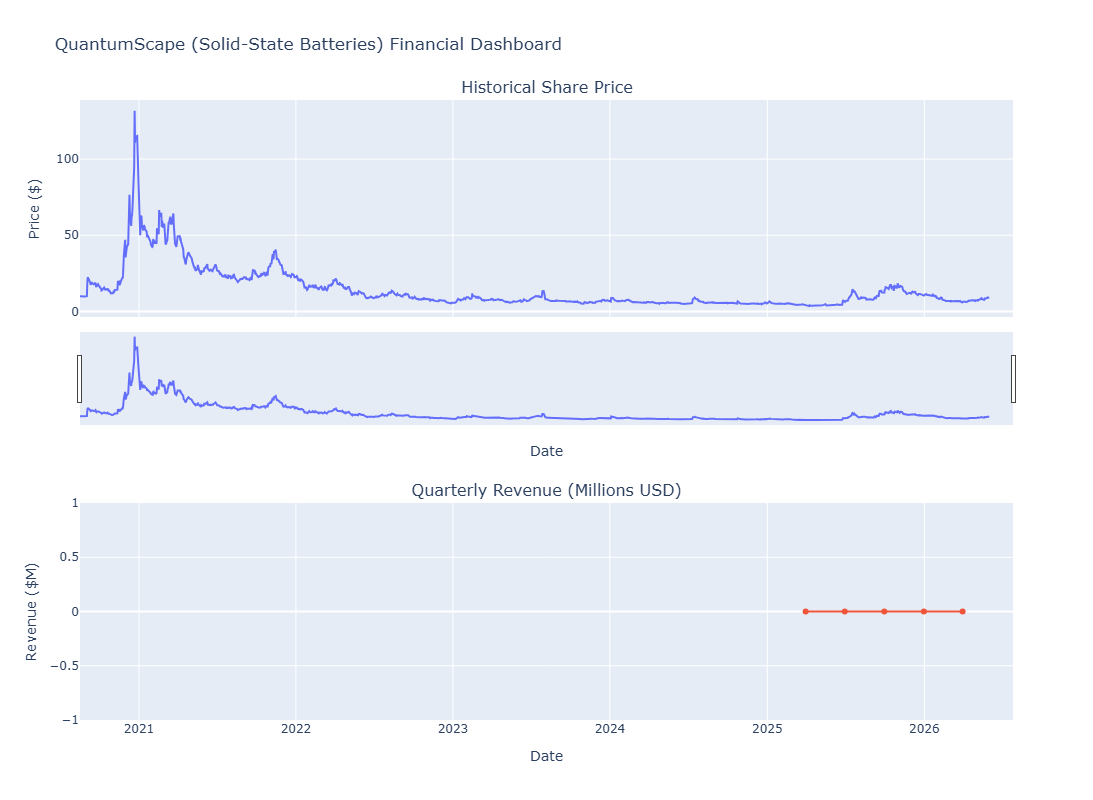

In [3]:
qs_stock, qs_revenue = extract_financial_data("QS")
make_graph(qs_stock, qs_revenue, "QuantumScape (Solid-State Batteries)")

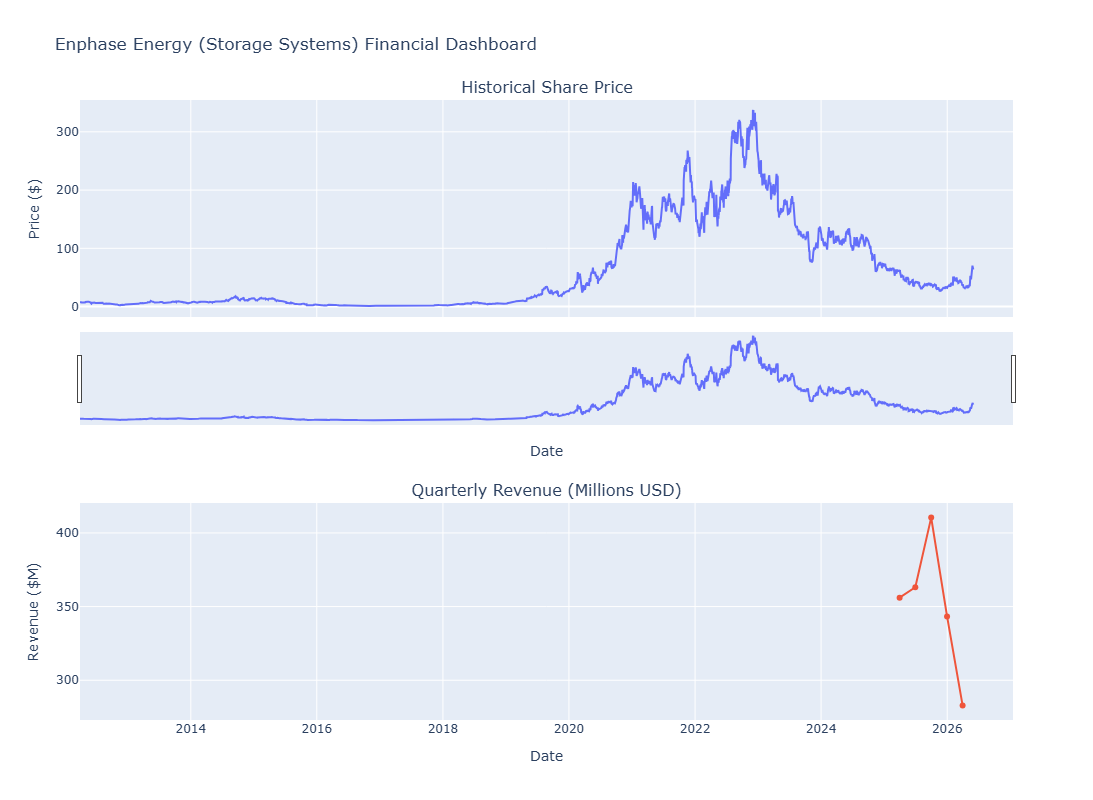

In [4]:
enph_stock, enph_revenue = extract_financial_data("ENPH")
make_graph(enph_stock, enph_revenue, "Enphase Energy (Storage Systems)")

# Energy Storage Financial Analytics Dashboard

An automated data pipeline written in Python that extracts, cleans, and visualizes market capitalization data and revenue performance for key entities in the grid-scale and next-generation battery sectors.

## Project Architecture
- **Data Acquisition:** Utilizes the `yfinance` API to retrieve maximum historical share prices and structural corporate balance sheets.
- **Data Engineering:** Dynamically transposes quarterly metrics, handles missing inputs, converts object types, and normalizes standard revenue scales into millions USD.
- **Visualization:** Renders synchronized, dual-panel time-series plots via `Plotly` to map capital market valuations directly against operational earnings.

## Target Companies Analyzed
1. **QuantumScape (QS):** Focusing on solid-state lithium-metal architectures.
2. **Enphase Energy (ENPH):** Representing decentralized microinverters and residential battery modular systems.

## How to Run
1. Install dependencies: `pip install yfinance pandas plotly`
2. Run the notebook: `jupyter notebook Energy_Storage_Dashboard.ipynb`